## Введение

- Ранее мы узнали, что временные ряды — это данные, которые измеряются через равные интервалы.
- Мы также узнали, что данные временных рядов можно разложить на три части: тренд, сезонность и остатки.
- Теперь мы углубимся в обсуждение важной концепции, называемой **стационарностью**.
- Четкое понимание этой концепции заложит основу, необходимую для понимания более сложных стратегий моделирования, которые мы представим позже.

In [1]:
# Imports
import warnings
warnings.filterwarnings('ignore')
from io import BytesIO
import requests
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import quad
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
np.random.seed(0) # Reproducibility

## Стационарный временной ряд

### Что такое стационарность?

- 💡 Интуиция: временной ряд стационарен, когда нет никаких изменений в базовой системе, которая его генерирует.
- Далее мы определяем:
- Строгую стационарность.
- Слабую стационарность.
- Что нужно проверить на практике.

- Strict stationarity is very difficult to verify, especially from a limited amount of data.
- For this reason, one checks the *Weak stationarity*.

- Строгая стационарность + условие 2 $\implies$ слабая стационарность

- Среднее значение, дисперсия и периодическая составляющая (она же сезонность) должны быть знакомы из предыдущей лекции.
- Автокорреляция может быть незнакома.
- Давайте начнем с простого примера стационарного временного ряда.

In [2]:
def run_sequence_plot(x, y, title, xlabel="Time", ylabel="Values", ax=None):
    if ax is None:
        _, ax = plt.subplots(1,1, figsize=(10, 3.5))
    ax.plot(x, y, 'k-')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    return ax

In [3]:
T = 200
time = np.arange(T)
stationary = np.random.normal(loc=0, scale=1.0, size=(T))

- Мы можем легко проверить, что белый шум имеет постоянное среднее значение, постоянную дисперсию и не имеет периодичности.
- А как насчет автокорреляции?

- Допустим, вы хотите узнать, коррелирует ли сегодняшняя температура больше со вчерашней температурой или с температурой двухдневной давности.
- Вы можете проверить это, вычислив корреляцию между исходным временным рядом и тем же рядом, отложенным на 1 шаг.
- Второе значение исходного временного ряда будет сравниваться с первым из задержанного временного ряда.
- Третье исходное значение будет сравниваться со вторым из задержанного.
- И так далее.


583 / 5 000
Ковариация $X(t_1)$ и $X(t_2)$ называется *автоковариацией* и немного отличается от автокорреляции. - Автокорреляция:

$$R_{xx}(t_1,t_2)=\mathbb{E}[X(t_1)X(t_2)]$$

- Автоковариация:

$$C_{xx}(t_1,t_2)=\mathbb{E}[(X(t_1)−\mu_{t_1})(X(t_2)−\mu_{t_2})]=R_{xx}(t_1,t_2)−\mu_{t_1}\mu_{t_2}$$

- $\mu_{t_1}$ и $\mu_{t_2}$ являются средними значениями временного ряда в моменты времени $t_1$ и $t_2$ соответственно.
- Если $X(t)$ имеет нулевое среднее, автокорреляция и автоковариация совпадают.
- Поскольку получение временного ряда с нулевым средним значением является тривиальной задачей, мы будем использовать эти два термина как взаимозаменяемые.

**Пример: постоянная автокорреляция**

- Временной ряд суточной температуры в определенном месте за год.
- Если в этом месте очень стабильный климат, то ежедневные изменения температуры могут быть минимальными и постоянными в течение года.
- Тогда автокорреляция будет относительно постоянной.
- Например, корреляция между сегодняшней температурой и завтрашней температурой примерно такая же, как корреляция между температурой 30 дней назад и 29 дней назад.

#### Постоянная и непостоянная автокорреляция

- Рассмотрим два временных ряда $X$ и $Y$.
- В $X$ автокорреляция постоянна во времени.
- В $Y$ автокорреляция меняется после 100 шагов.
- Для этого примера мы будем использовать процесс AR (подробнее об AR позже).


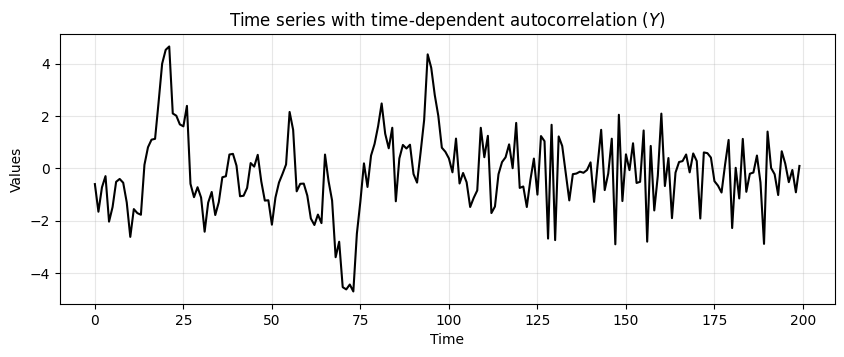

In [7]:
ma1 = np.array([1])
ar2 = np.array([1, -0.9])
AR_object2 = ArmaProcess(ar2, ma1)
ar3 = np.array([1, 0.3])
AR_object3 = ArmaProcess(ar3, ma1)

time_dependent_autocorr_ts_1 = AR_object2.generate_sample(nsample=100)
time_dependent_autocorr_ts_2 = AR_object3.generate_sample(nsample=100)
time_dependent_autocorr_ts = np.concatenate([time_dependent_autocorr_ts_1,
                                             time_dependent_autocorr_ts_2])

run_sequence_plot(time, time_dependent_autocorr_ts, title="Time series with time-dependent autocorrelation ($Y$)");

- Вторая часть характеризуется *более слабой автокорреляцией*.
- Временной ряд более нестабилен и меньше подвержен влиянию своих прошлых значений.

- Если аналитическое выражение временного ряда известно, можно проверить условия стационарности.
- На практике процесс генерации временного ряда может быть неизвестен, и нам понадобятся другие инструменты для проверки стационарности.
- Начало анализа с просмотра `run_sequence_plot` является отличной отправной точкой.

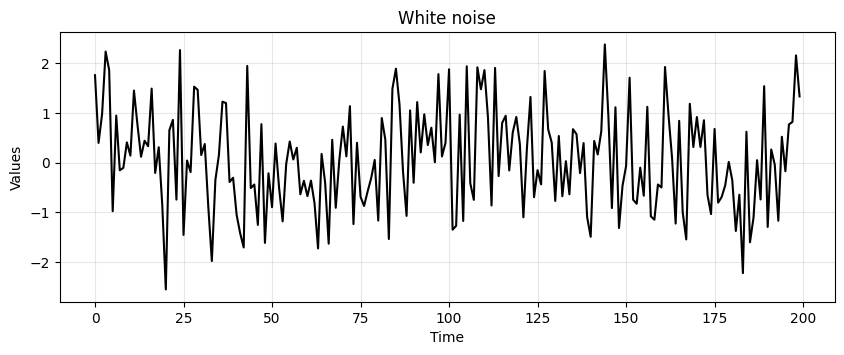

In [5]:
run_sequence_plot(time, stationary, title="White noise");

In [6]:
# seed to start series
seed = 3.14

# Random Walk
rand_walk = np.empty_like(time, dtype='float')
for t in time:
    rand_walk[t] = seed + np.random.normal(loc=0, scale=2.5, size=1)[0]
    seed = rand_walk[t]

- Обратите внимание, как текущее значение сильно коррелирует с прошлыми значениями и колеблется гораздо меньше, чем белый шум.
- Случайное блуждание нестационарно.
- Почему 🤔?

**Изменение дисперсии**

- При случайном блуждании дисперсия меняется со временем.
- Это нарушает условие №2 слабой стационарности.
- В частности, дисперсия *увеличивается* линейно с течением времени, поскольку эффекты инноваций накапливаются.
- Давайте рассмотрим это подробнее.

2. At $t = 1$ we have:
   - $X(1) = X(0) + \epsilon_1$.
   - Variance: $\text{Var}(X(1)) = \text{Var}(\epsilon_1) = \sigma^2$.

4. At a general time $t$ we have:
   - $X(t) = X(t-1) + \epsilon_t = X(0) + \epsilon_1 + \epsilon_2 + \ldots + \epsilon_t$.
   - Again, using the independence of the $\epsilon$ terms and the fact that each has variance $\sigma^2$ we get:
   
   $$\text{Var}(X(t)) = \text{Var}(\epsilon_1) + \text{Var}(\epsilon_2) + \ldots + \text{Var}(\epsilon_t) = t\sigma^2$$

In [12]:
trend = (time * 2.75) + stationary
heteroscedasticity = stationary * (1 + time / time.max())

- Являются ли эти данные стационарными?

#### Гетероскедастический временной ряд (Heteroscedastic time series)

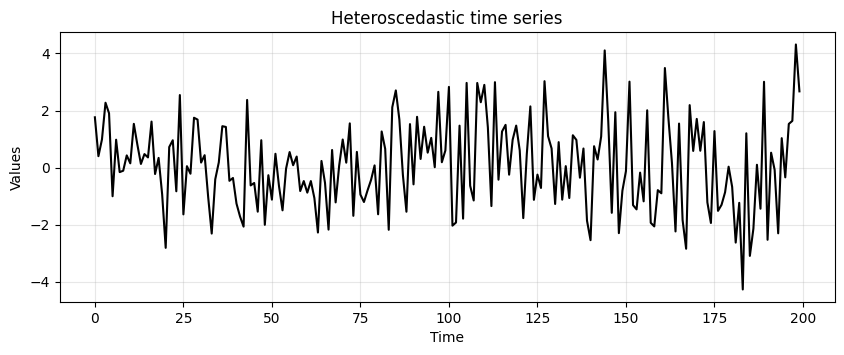

In [13]:
run_sequence_plot(time, heteroscedasticity, title="Heteroscedastic time series");

- Нет, дисперсия меняется со временем.

In [14]:
seasonality = 20 + np.sin(2*np.pi*time/12)*20
trend_seasonality = trend + seasonality

- Является ли этот временной ряд стационарным?

#### Time series with trend and seasonality

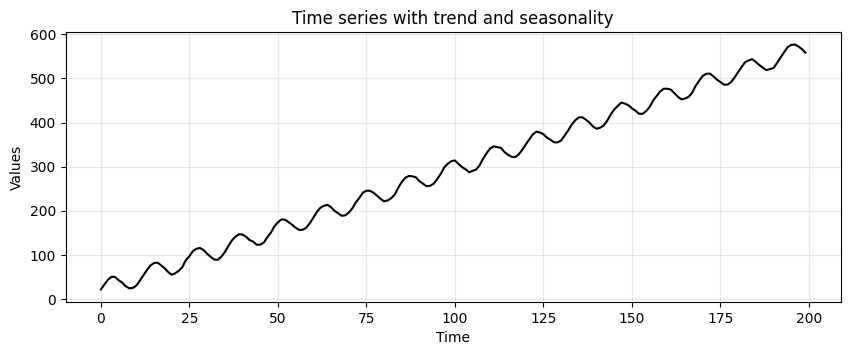

In [15]:
run_sequence_plot(time, trend_seasonality, title="Time series with trend and seasonality");

- Нет, среднее значение меняется со временем из-за тенденции И присутствует периодическая составляющая.

- Это периодический сигнал?
- Удовлетворяет ли он условиям слабой стационарности?

- **mean** $\mu + R \sin(\lambda t + \psi)$ равно $\mu$, что является константой.
- Условие №1 выполнено ✌
- Давайте также проверим его с помощью кода.

- **Дисперсия** случайной величины $X$, заданная как:

$$\text{Var}(X) = \mathbb{E}[X^2] - (\mathbb{E}[X])^2$$

- Давайте сначала рассмотрим $\sin(\lambda t + \psi)$, для которой мы знаем $\mathbb{E}[\sin(\lambda t + \psi)] = 0$
- Дисперсия упрощается до:

$$\text{Var}(\sin(\lambda t + \psi)) = \mathbb{E}[\sin^2(\lambda t + \psi)]$$

- Для любого $x$ имеем, что $\int_{-\pi}^{\pi} \sin^2(x) dx = \pi$

- Это дает нам:

$$\text{Var}(\sin(\lambda t + \psi)) = \mathbb{E}[\sin^2(\lambda t + \psi)] = \frac{1}{2\pi}\pi = \frac{1}{2}$$

In [16]:
R = 3
lamb = 6.5
t = 4

def func_sin2(psi):
    return ((R*np.sin(lamb*t + psi))**2) / (2*np.pi)

# Perform the numerical integration
variance, _ = quad(func_sin2, -np.pi, np.pi)
print(variance)

4.5


- Теперь используем тригонометрическое тождество:

$$\sin(A) \sin(B) = \frac{1}{2}[\cos(A - B) - \cos(A + B)]$$

- Применяя это тождество, получаем:

\begin{align*}
\text{Cov}(x_t, x_{t+h}) & = R^2 \mathbb{E}\left[\frac{1}{2}[\cos(\lambda t + \psi - \lambda (t + h) - \psi) - \cos(\lambda t + \psi + \lambda (t + h) + \psi)]\right]\\
& = \frac{R^2}{2} \mathbb{E}\left[\cos(\lambda h) - \cos(2\lambda t + 2\psi + \lambda h)\right]\\
& = \frac{R^2}{2} \mathbb{E}\left[\cos(\lambda h)\right] - \frac{R^2}{2} \mathbb{E}\left[\cos(2\lambda t + 2\psi + \lambda h)\right] \end{align*}

В заключение, временной ряд $X(t) = \mu + R \sin(\lambda t + \psi)$ является слабо стационарным:

- его среднее значение постоянно,
- его дисперсия постоянна,
- его автоковариация зависит только от лага $h$.

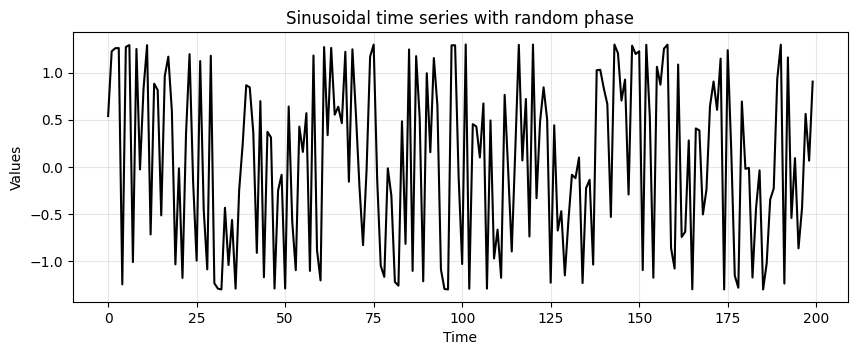

In [17]:
R = 1.3
lamb = 3.5
phi = np.random.uniform(-np.pi, np.pi, len(time))
cyc = R * np.sin(lamb * time + phi)
run_sequence_plot(time, cyc, title="Sinusoidal time series with random phase");

---

Далее мы рассмотрим практические методы, используемые для определения того, является ли временной ряд стационарным или нет.

В частности, мы рассмотрим:
1. Графики последовательности выполнения (Run-sequence plot)
2. Сводные статистики
3. Расширенный тест Дики-Фуллера

### Сводная статистика (Summary Statistics)

Вот как выглядит стационарный временной ряд.

Вот как выглядит нестационарный временной ряд.

- Давайте рассмотрим пример, основанный на временном ряде «тренда», который мы создали ранее.

Summary statistics:

- Хотя дисперсия относительно постоянна с течением времени, среднее значение явно меняется, что означает, что эти данные не являются стационарными.
- Мы ожидаем некоторые колебания значений.
- Маловероятно, что среднее значение и дисперсия будут абсолютно одинаковыми во всех фрагментах, но они должны быть близки.

### Расширенный тест Дики-Фуллера

- Это статистическая процедура для определения того, является ли временной ряд стационарным или нет.
- Мы обсудим тест более подробно на следующих лекциях.
- На данный момент нам нужно знать следующее:
1. **Нулевая гипотеза:** $H_0$: ряд нестационарный.
2. **Альтернативная гипотеза:** $H_A$: ряд стационарный.

Пример: $p = 0,0001 \rightarrow$ отвергаем $H_0 \rightarrow$ временной ряд стационарен

 Тест ADF может быть неточным при небольших наборах данных или при наличии гетероскедастичности.
- Лучше всего сочетать ADF с другими методами (графиками последовательности запусков, сводной статистикой, гистограммами и т. д.).

In [18]:
adf, pvalue, usedlag, nobs, critical_values, icbest = adfuller(stationary)

In [19]:
print(f"ADF: {adf:.2f}")

ADF: -13.56


In [20]:
print(f"p-value: {pvalue}")

p-value: 2.300172138070656e-25


In [21]:
print(f"nobs: {nobs}")

nobs: 199


In [22]:
print(f"critical values: {critical_values}")

critical values: {'1%': np.float64(-3.4636447617687436), '5%': np.float64(-2.8761761179270766), '10%': np.float64(-2.57457158581854)}


- Вы могли заметить два вывода, которые мы не обсудили.
- Смотрите [statsmodels docs](http://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.adfuller.html) для описания ``usedlag`` и ``icbest``.

In [23]:
adf, pvalue, usedlag, nobs, critical_values, icbest = adfuller(trend, regression='c')
print(f"ADF: {adf:.2f}")
print(f"p-value: {pvalue:.3f}")

ADF: 0.82
p-value: 0.992


### ADF on random walk  (ADF на случайном блуждании)

- Наконец, мы запускаем тест ADF на временном ряду `rand_walk`.

- Как мы уже обсуждали, случайное блуждание нестационарно, поскольку его дисперсия $\sigma^2t$ не постоянна во времени.
- В следующем разделе мы узнаем, как сделать этот временной ряд стационарным.

---

- Существует несколько способов преобразования нестационарных временных рядов:

Преобразование | Эффект
:---|:---
Вычитание тренда | Постоянное среднее
Применение логарифма | Постоянная дисперсия
Дифференцирование | Удаление автокорреляции
Сезонная дифференциация | Удаление периодической составляющей

- Часто вам придется делать несколько из этого с одним набором данных.
- Обратите внимание, что это всего лишь небольшое подмножество всех возможных способов преобразования нестационарных временных рядов.

- Давайте проведем тест ADF перед трансформацией.

- Нестационарно, как и ожидалось.
- Далее применяем преобразование.

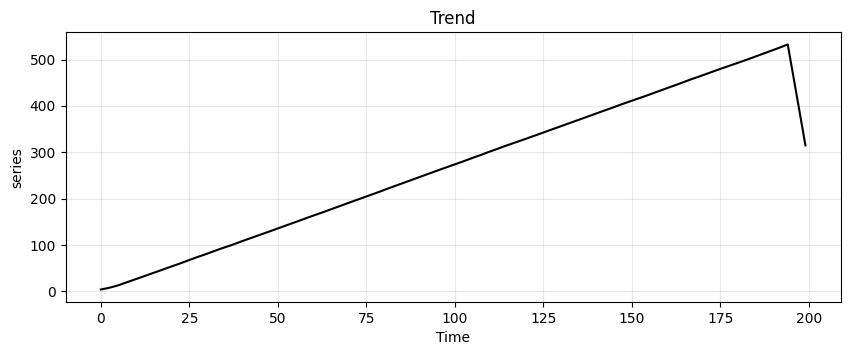

In [26]:
window = 12
kernel = np.ones(window) / window
est_trend = np.convolve(trend, kernel, mode='same')
est_residual = trend - est_trend

run_sequence_plot(time, est_trend, title="Trend", ylabel="series");

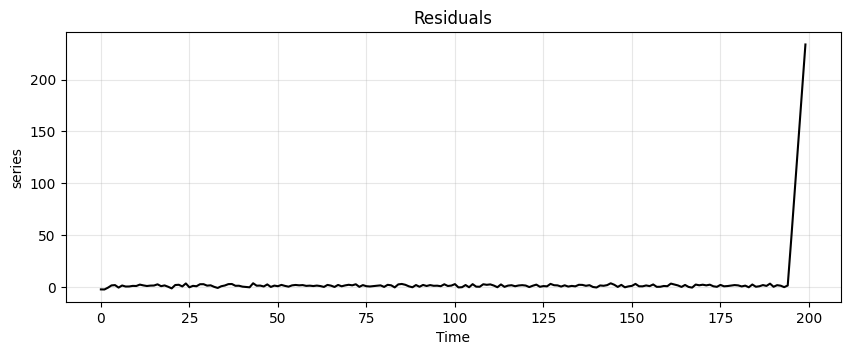

In [27]:
run_sequence_plot(time, est_residual, title="Residuals", ylabel="series");

In [28]:
print(est_residual)

[-2.19629106e+00 -2.26436023e+00 -5.27333021e-01  1.66009043e+00
  1.94003868e+00 -4.58467486e-01  1.57687602e+00  5.59014945e-01
  6.30360150e-01  1.18875040e+00  1.08113038e+00  2.42248355e+00
  1.66490447e+00  1.07862682e+00  1.45937658e+00  1.55333526e+00
  2.69348833e+00  9.34218273e-01  1.63548078e+00  3.42590933e-01
 -1.22496642e+00  2.01481739e+00  2.26903984e+00  6.59213606e-01
  3.53159016e+00 -1.79353445e-01  1.21808256e+00  8.46373186e-01
  2.78587084e+00  2.82347942e+00  1.43419191e+00  1.74402900e+00
  2.56685275e-01 -8.00235001e-01  8.42242559e-01  1.56161469e+00
  2.87633780e+00  3.00352843e+00  1.28277069e+00  1.33628363e+00
  4.61473235e-01  1.65415197e-01 -1.72598839e-01  3.72146246e+00
  1.37896156e+00  1.49288442e+00  6.20729588e-01  2.60620298e+00
  1.94865969e-01  1.45618287e+00  9.00326885e-01  2.13468183e+00
  1.17526201e+00  4.53895523e-01  1.70136477e+00  2.07942575e+00
  1.72984551e+00  1.95894017e+00  1.19824493e+00  1.41247325e+00
  1.03784970e+00  1.48425

In [29]:
adf_after, pvalue_after, _, _, _, _ = adfuller(est_residual[6:-6])
print(f"ADF: {adf_after:.2f}")
print(f"p-value: {pvalue_after:.3f}")

ADF: -6.44
p-value: 0.000


### Стабилизация дисперсии с помощью логарифмического преобразования

- Этот прием полезен при работе с гетероскедастическими данными.
- Логарифм сжимает части временного ряда, где дисперсия выше.
- Таким образом, дисперсия становится более однородной.
- Давайте снова построим график гетероскедастического временного ряда, чтобы запомнить, как он выглядит.

- Let's run the ADF test.

**⚠ Внимание**

- ADF говорит, что мы отвергаем $H_0$ (по крайней мере на уровне достоверности $\alpha=0.05$) в пользу альтернативы, что временной ряд является стационарным.
- Однако график ясно показывает, что дисперсия не является постоянной во времени.

- Давайте теперь применим логарифмическое преобразование.
- Перед этим мы вычитаем минимум и добавляем небольшую константу
- Таким образом мы гарантируем, что все значения будут положительными

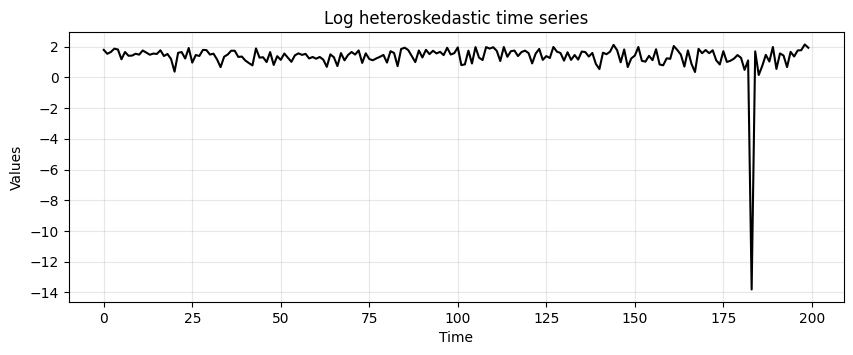

In [30]:
shifted_hetero = heteroscedasticity - heteroscedasticity.min() + 1e-6
log_new_hetero = np.log(shifted_hetero)
run_sequence_plot(time, log_new_hetero, title="Log heteroskedastic time series");

📨 Вывод:

- Тест ADF может не обнаружить нестационарность из-за гетероскедастичности.
- Всегда отображайте данные на графике.
- Не полагайтесь на один инструмент для определения стационарности.

- Мы знаем, что `rand_walk` был создан с задержкой 1.
- Таким образом, стационарный временной ряд может быть получен как:

$$\hat{X}(t) = X(t) - X(t-1)$$

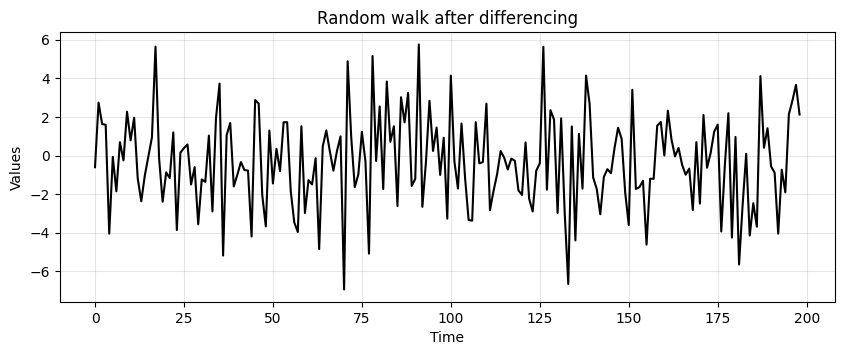

In [31]:
difference = np.diff(rand_walk)
run_sequence_plot(time[:-1], difference, title="Random walk after differencing");

In [32]:
adf_after, pvalue_after, _, _, _, _ = adfuller(difference)
print(f"ADF: {adf_after:.2f}")
print(f"p-value: {pvalue_after:.3f}")

ADF: -15.61
p-value: 0.000


- Давайте рассмотрим другой пример.
- Мы создаем небольшой фрейм данных от 1 до 10 (линейный и квадратный).

- Сделайте первый временной ряд (``исходный``) стационарным, чтобы среднее значение и дисперсия не менялись для подокна.

**💡 ПРИМЕЧАНИЕ:** Это похоже на взятие производной первого порядка.

- Обратите внимание, что нам нужно дважды дифференцировать экспоненциальный временной ряд.
- Каждый раз, когда мы делаем дифференцирование, мы теряем часть данных.

In [36]:
df = pd.DataFrame({"squared": (np.arange(1, len(time) + 1, dtype=float) ** 2)})
np.log(df.squared).to_frame("log")

,log
0,0.000000
1,1.386294
2,2.197225
3,2.772589
4,3.218876
...,...
195,10.556229
196,10.566407
197,10.576534
198,10.586610


- В общем случае мы не знаем оптимального лага для выполнения дифференциации.
- Как определить оптимальный порядок дифференциации, будет рассмотрено позже.

- После сезонной дифференциации временной ряд станет на $L$ шагов короче.
- Обратите внимание, что мы можем выполнить стандартную дифференциацию каскадом к сезонной дифференциации, если нам нужно удалить также тренд поверх сезонности.
- Давайте посмотрим на это на временном ряду `trend_seasonality`.

In [37]:
trend_seasonality_d12 = trend_seasonality[12:] - trend_seasonality[:-12]
trend_seasonality_d12_d1 = np.diff(trend_seasonality_d12, n=1)

adf_after, pvalue_after, _, _, _, _ = adfuller(trend_seasonality_d12_d1)
print(f"ADF: {adf_after:.2f}")
print(f"p-value: {pvalue_after:.3f}")

ADF: -5.28
p-value: 0.000


## Резюме

В этой лекции мы узнали:
1. Что означает, что временной ряд является стационарным.
2. Набор известных стационарных и нестационарных временных рядов.
2. Общие инструменты для определения стационарности.
3. Полезные преобразования нестационарного в стационарное.

### Упражнение 1

- Загрузите два временных ряда `stationarity_ts1` и `stationarity_ts2`, выполнив код ниже.

1. Постройте два временных ряда с помощью графика последовательности запусков.
4. На основе графика обсудите, является ли каждый временной ряд стационарным или нет.

### Упражнение 3
Если один или оба набора данных из упражнений один и два нестационарны, примените преобразования, которые вы изучили в этом разделе, чтобы сделать их таковыми. Затем примените методы, которые вы изучили, чтобы обеспечить стационарность.

In [35]:
# Упражнение 1 (подготовка): загрузка временных рядов
def _load_npy(url: str, timeout_s: int = 30):
    resp = requests.get(url, timeout=timeout_s)
    resp.raise_for_status()
    return np.load(BytesIO(resp.content))

base = "https://zenodo.org/records/10897398/files"
stationarity_ts1 = _load_npy(f"{base}/stationarity_ts1.npy?download=1")
stationarity_ts2 = _load_npy(f"{base}/stationarity_ts2.npy?download=1")

print("stationarity_ts1:", stationarity_ts1.shape)
print("stationarity_ts2:", stationarity_ts2.shape)


stationarity_ts1: (100,)
stationarity_ts2: (100,)


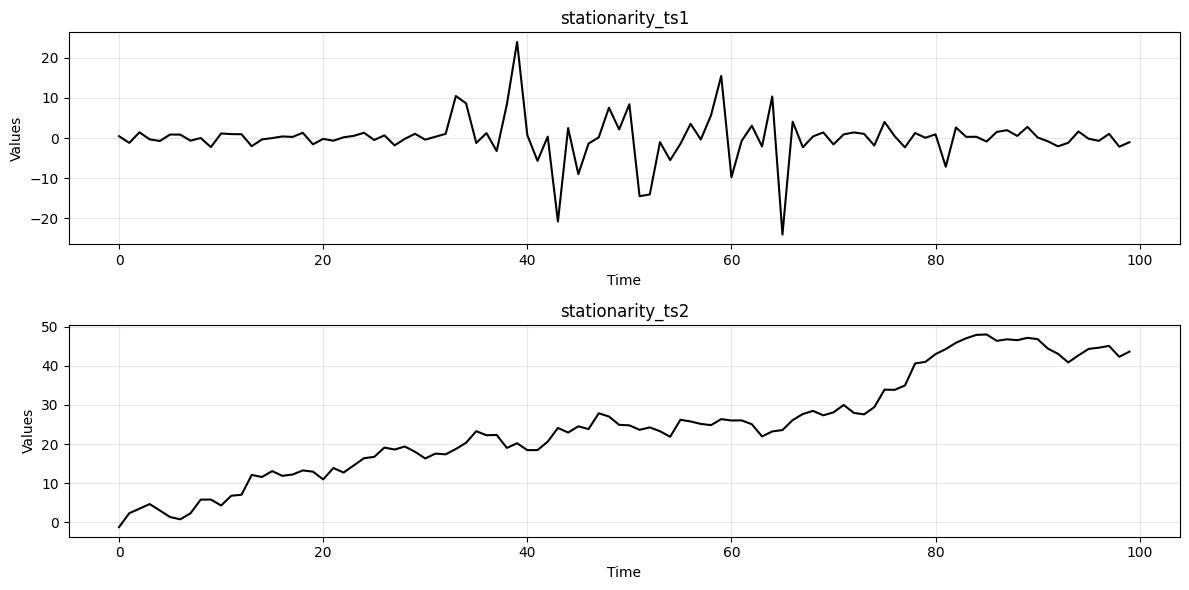

In [38]:
# Упражнение 1: run-sequence plots
t1 = np.arange(len(stationarity_ts1))
t2 = np.arange(len(stationarity_ts2))

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=False)
run_sequence_plot(t1, stationarity_ts1, title="stationarity_ts1", ax=axes[0])
run_sequence_plot(t2, stationarity_ts2, title="stationarity_ts2", ax=axes[1])
plt.tight_layout()
plt.show()


Интерпретация для упражнения 1:

- Если на графике видно изменение среднего (дрейф/тренд) или «расширение/сжатие» разброса, то ряд **нестационарен**.
- Ниже дополнительно проверим это количественно (ADF-тест, статистики по окнам).

### Упражнение 2

Проверьте стационарность количественно: сравните статистики по подокнам, посмотрите распределение (гистограммы) и выполните ADF-тест.

ts1: ADF p-value = 0.0320


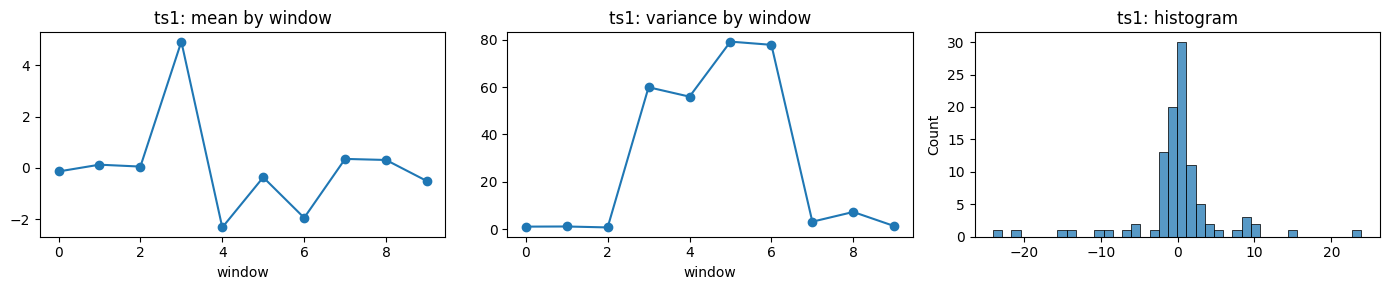

ts2: ADF p-value = 0.6189


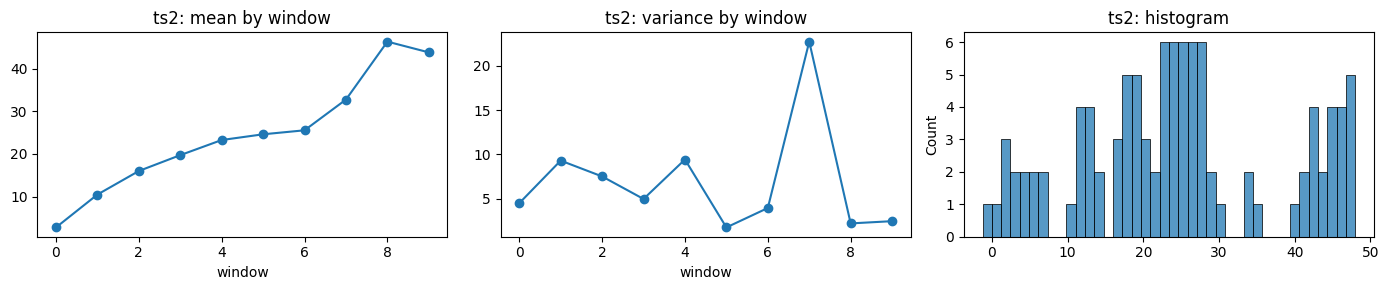

In [39]:
import seaborn as sns

def _adf_pvalue(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    stat, pvalue, *_ = adfuller(x, autolag="AIC")
    return float(pvalue)

def _window_stats(x: np.ndarray, n_windows: int = 10):
    chunks = np.array_split(np.asarray(x, dtype=float), n_windows)
    means = np.array([np.nanmean(c) for c in chunks])
    vars_ = np.array([np.nanvar(c) for c in chunks])
    return means, vars_

for name, ts in [("ts1", stationarity_ts1), ("ts2", stationarity_ts2)]:
    p = _adf_pvalue(ts)
    means, vars_ = _window_stats(ts, n_windows=10)
    print(f"{name}: ADF p-value = {p:.4f}")

    fig, axes = plt.subplots(1, 3, figsize=(14, 3))
    axes[0].plot(means, marker="o")
    axes[0].set_title(f"{name}: mean by window")
    axes[0].set_xlabel("window")

    axes[1].plot(vars_, marker="o")
    axes[1].set_title(f"{name}: variance by window")
    axes[1].set_xlabel("window")

    sns.histplot(ts, bins=40, ax=axes[2])
    axes[2].set_title(f"{name}: histogram")

    plt.tight_layout()
    plt.show()


ts1: best variant = log(x+25), ADF p-value=0.0000
ts2: best variant = log+diff1, ADF p-value=0.0000


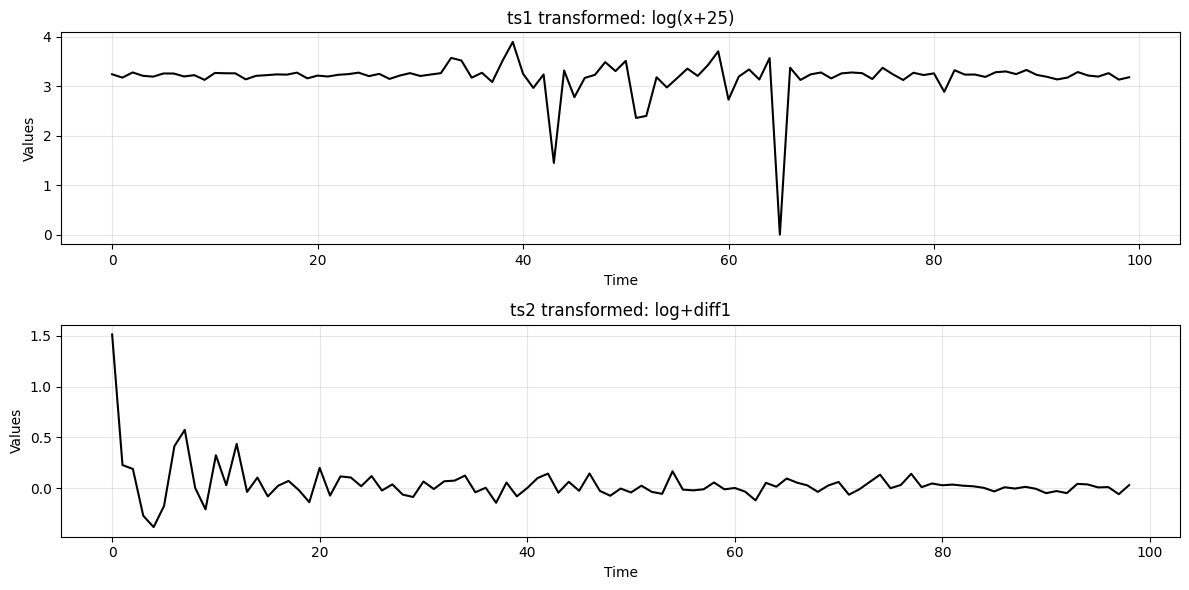

In [40]:
# Упражнение 3: привести нестационарные ряды к стационарным
def _log_shift(x: np.ndarray):
    x = np.asarray(x, dtype=float)
    min_val = np.nanmin(x)
    shift = (1.0 - min_val) if min_val <= 0 else 0.0
    return np.log(x + shift), shift

def _diff(x: np.ndarray, lag: int = 1):
    x = np.asarray(x, dtype=float)
    return np.diff(x, n=lag)

def _best_stationary_variant(x: np.ndarray, name: str):
    variants = []
    variants.append(("raw", x))
    x_log, shift = _log_shift(x)
    variants.append((f"log(x+{shift:.3g})", x_log))
    variants.append(("diff1", _diff(x, 1)))
    variants.append((f"log+diff1", _diff(x_log, 1)))

    scored = []
    for vname, v in variants:
        try:
            p = _adf_pvalue(v)
        except Exception:
            p = float("nan")
        scored.append((p, vname, v))

    scored_valid = [s for s in scored if np.isfinite(s[0])]
    scored_valid.sort(key=lambda t: t[0])
    best_p, best_name, best_v = scored_valid[0]
    print(f"{name}: best variant = {best_name}, ADF p-value={best_p:.4f}")
    return best_name, best_v, best_p

best1_name, best1, _ = _best_stationary_variant(stationarity_ts1, "ts1")
best2_name, best2, _ = _best_stationary_variant(stationarity_ts2, "ts2")

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=False)
run_sequence_plot(np.arange(len(best1)), best1, title=f"ts1 transformed: {best1_name}", ax=axes[0])
run_sequence_plot(np.arange(len(best2)), best2, title=f"ts2 transformed: {best2_name}", ax=axes[1])
plt.tight_layout()
plt.show()
